In [45]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from xgboost import XGBRegressor
import optuna
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.dates as mdates
import shap
import joblib
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

In [ ]:
# 1. Load Data
df = pd.read_csv('data_for_optimizing.csv')
df['week_start'] = pd.to_datetime(df['week_start'])

# 2. Pre-processing & Patching
# Patch distributor_code NaNs using ffill/bfill within kode_gudang
if 'distributor_code' in df.columns and 'kode_gudang' in df.columns:
    df['distributor_code'] = df.groupby('kode_gudang')['distributor_code'].ffill().bfill()
    df['distributor_code'] = df['distributor_code'].fillna('UNKNOWN_DIST')

# 3. Strict Temporal Split (Chronological sorting before split)
df = df.sort_values(by=['week_start']).reset_index(drop=True)

# 1. Hitung dulu rata-rata serapan harian gudang di masa lalu (dishift agar jujur)
df['rolling_daily_sellout'] = df.groupby(['kode_gudang', 'material_code'])['total_sellout_gudang'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).mean()
) / 7.0

# 2. Fitur Dewa: Sisa Hari Ketahanan Stok di akhir minggu lalu
# Rumus: Stok Fisik Minggu Lalu / Kecepatan Jual Harian
df['lag_1w_days_of_supply'] = df['lag_1w_stock_toko'] / (df['rolling_daily_sellout'] + 1e-5)

# Clip nilai ekstrem (misal jika barang tidak laku sama sekali, sisa stok = 999 hari)
df['lag_1w_days_of_supply'] = df['lag_1w_days_of_supply'].clip(upper=60)

In [ ]:
# Rule 1: Allowlist Features
target = 'actual_tonase_in'
cat_features = ['kode_gudang', 'material_code', 'provinsi', 'distributor_code']
lag_features = [
    'lag_1w_actual', 'lag_2w_actual', 'lag_4w_actual', 'rolling_4w_actual_mean', 'rolling_4w_actual_std', 
    'lag_1w_sellout_gudang', 'lag_1w_stock_toko', 'lag_1w_vol_order_dist', 'lag_1w_fulfillment_ratio', 'lag_1w_days_of_supply'
]
time_features = ['month', 'quarter', 'week_of_year', 'month_sin', 'month_cos', 'week_sin', 'week_cos']

allowlist_x = cat_features + lag_features + time_features

# Keep only the columns we need
keep_cols = ['week_start', target] + allowlist_x
df = df[[c for c in keep_cols if c in df.columns]]

# Categorical Encoding
encoders = {}
for col in cat_features:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

# Split Index (80%)
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

actual_allowlist_x = [c for c in allowlist_x if c in df.columns]
X_train = train[actual_allowlist_x]
y_train = train[target]
X_test = test[actual_allowlist_x]
y_test = test[target]

print(f"Train Set: {X_train.shape[0]} rows | Test Set: {X_test.shape[0]} rows")

Train Set: 26592 rows | Test Set: 6648 rows


In [47]:
# 4. Modeling & Optuna
print("Tuning LightGBM...")
def objective_lgb(trial):
    params = {
        'objective': 'tweedie',
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'verbose': -1,
        'random_state': 42
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=100)
best_lgb = lgb.LGBMRegressor(**study_lgb.best_params, verbose=-1, random_state=42)
best_lgb.fit(X_train, y_train)

Tuning LightGBM...


,boosting_type,'gbdt'
,num_leaves,95
,max_depth,8
,learning_rate,0.011454540300074015
,n_estimators,436
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [48]:
print("Tuning XGBoost...")
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, verbose=False)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=100)
best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42)
best_xgb.fit(X_train, y_train, verbose=False)

Tuning XGBoost...


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9278185904876519
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [49]:
# 5. Supply Chain Metrics & Evaluation
pred_lgb = best_lgb.predict(X_test)
pred_xgb = best_xgb.predict(X_test)
rmse_lgb = np.sqrt(mean_squared_error(y_test, pred_lgb))
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

best_model = best_lgb if rmse_lgb < rmse_xgb else best_xgb
best_preds = pred_lgb if rmse_lgb < rmse_xgb else pred_xgb
model_name = "LightGBM" if rmse_lgb < rmse_xgb else "XGBoost"

print(f"\n[Case 2 - Block B] Selected Best Model: {model_name}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, best_preds)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, best_preds):.2f}")
print(f"R-squared: {r2_score(y_test, best_preds):.4f}")

wape_score = wape(y_test, best_preds)
print(f"WAPE: {wape_score:.4f}")
forecast_accuracy = max(0, 1 - wape_score) * 100
print(f"Forecast Accuracy (Berdasarkan WAPE): {forecast_accuracy:.2f}%")
mape_score = mean_absolute_percentage_error(y_test, best_preds)
print(f"MAPE: {mape_score:.4f}")


[Case 2 - Block B] Selected Best Model: LightGBM
RMSE: 72.92
MAE: 47.89
R-squared: 0.4298
WAPE: 0.5551
Forecast Accuracy (Berdasarkan WAPE): 44.49%
MAPE: 82027624888602800.0000



Top 10 Feature Importances:
               Feature  Importance
 lag_1w_days_of_supply    0.092322
         lag_1w_actual    0.090849
rolling_4w_actual_mean    0.084451
     lag_1w_stock_toko    0.083460
      distributor_code    0.078154
         lag_2w_actual    0.075361
 lag_1w_sellout_gudang    0.074345
 lag_1w_vol_order_dist    0.070816
         lag_4w_actual    0.068733
 rolling_4w_actual_std    0.053753


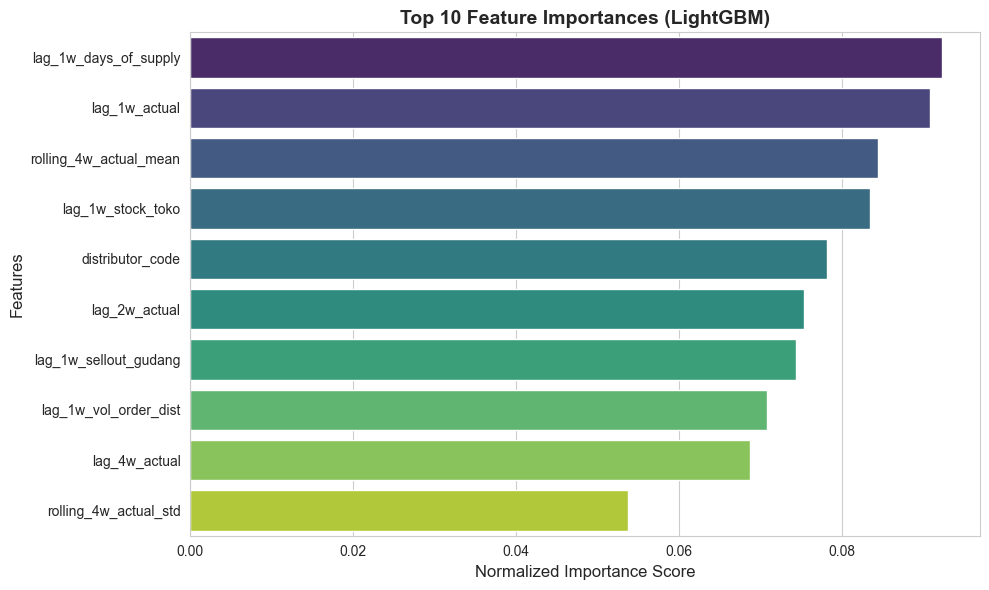

In [55]:
# Feature Importances
importances = best_model.feature_importances_
if np.sum(importances) > 0:
    importances = importances / np.sum(importances)
feat_imp = pd.DataFrame({'Feature': actual_allowlist_x, 'Importance': importances}).sort_values('Importance', ascending=False)
top_10_features = feat_imp.head(10)

print("\nTop 10 Feature Importances:")
print(top_10_features.to_string(index=False))

if top_10_features.iloc[0]['Importance'] > 0.8:
    print(f"\nWARNING: Feature '{top_10_features.iloc[0]['Feature']}' holds >80% importance ({top_10_features.iloc[0]['Importance']:.2%}!). Potential Target Leakage!")

# Set default seaborn style
sns.set_style("whitegrid")

# ==========================================
# VISUALISASI GRAFIK FEATURE IMPORTANCE
# ==========================================
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title(f'Top 10 Feature Importances ({model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Normalized Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

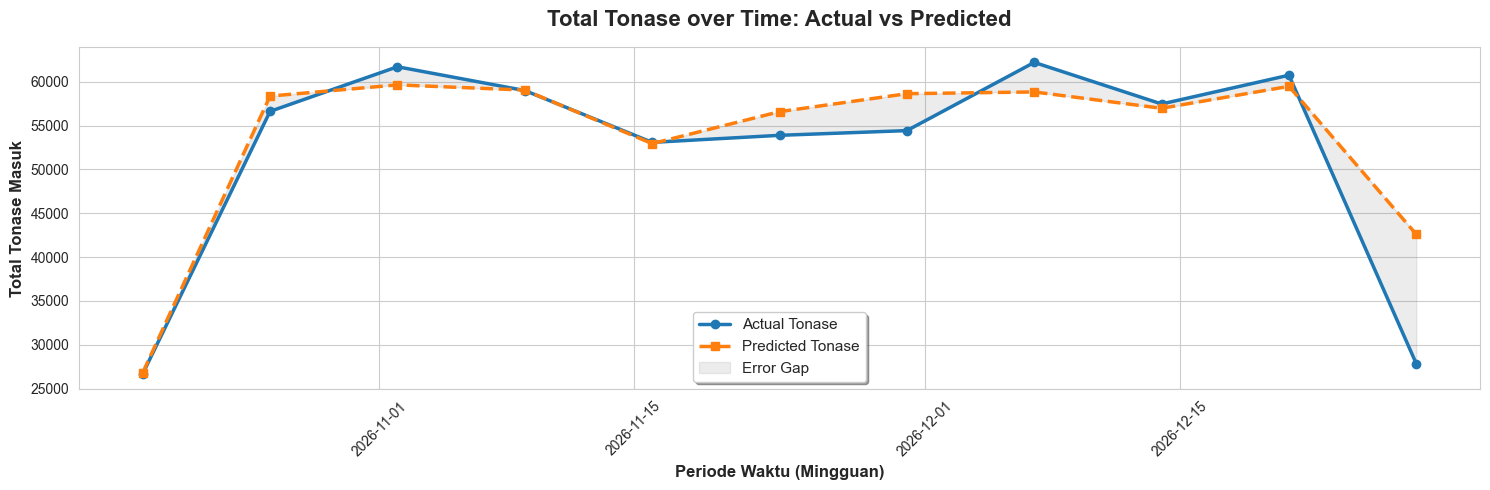

In [56]:
# ==========================================
# VISUALISASI TIME SERIES (ACTUAL VS PREDICTED)
# ==========================================
test['predicted_tonase'] = best_preds
time_series_eval = test.groupby('week_start')[['actual_tonase_in', 'predicted_tonase']].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(time_series_eval['week_start'], time_series_eval['actual_tonase_in'], 
         label='Actual Tonase', marker='o', color='#1f77b4', linewidth=2.5, markersize=6)
plt.plot(time_series_eval['week_start'], time_series_eval['predicted_tonase'], 
         label='Predicted Tonase', marker='s', color='#ff7f0e', linewidth=2.5, linestyle='--', markersize=6)
plt.fill_between(time_series_eval['week_start'], 
                 time_series_eval['actual_tonase_in'], 
                 time_series_eval['predicted_tonase'], 
                 color='gray', alpha=0.15, label='Error Gap')

plt.title('Total Tonase over Time: Actual vs Predicted', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Periode Waktu (Mingguan)', fontsize=12, fontweight='bold')
plt.ylabel('Total Tonase Masuk', fontsize=12, fontweight='bold')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.legend(loc='best', frameon=True, shadow=True, fontsize=11)
plt.tight_layout()
plt.show()


Calculating SHAP values...


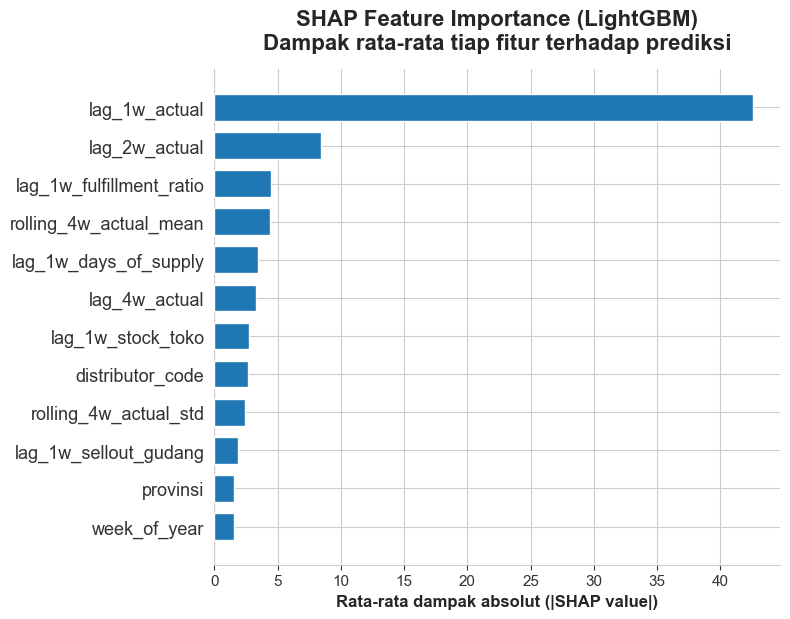

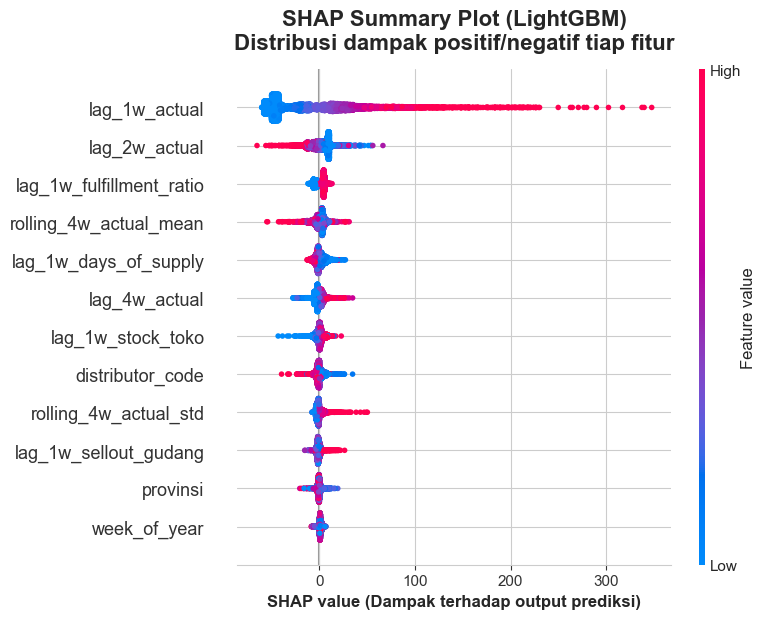

In [52]:
# ==========================================
# VISUALISASI SHAP EXPLAINER
# ==========================================
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(14, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, color="#1f77b4", max_display=12)
plt.title(f"SHAP Feature Importance ({model_name})\nDampak rata-rata tiap fitur terhadap prediksi", 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Rata-rata dampak absolut (|SHAP value|)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
shap.summary_plot(shap_values, X_test, show=False, max_display=12)
plt.title(f"SHAP Summary Plot ({model_name})\nDistribusi dampak positif/negatif tiap fitur", 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("SHAP value (Dampak terhadap output prediksi)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

plt.rcdefaults()

In [53]:
# Executive Roll-up
if 'provinsi' in encoders:
    test['provinsi_dec'] = encoders['provinsi'].inverse_transform(test['provinsi'])
else:
    test['provinsi_dec'] = 'UNKNOWN'
    
if 'material_code' in encoders:
    test['material_code_dec'] = encoders['material_code'].inverse_transform(test['material_code'])
else:
    test['material_code_dec'] = 'UNKNOWN'
    
rollup = test.groupby(['week_start', 'provinsi_dec', 'material_code_dec'])[['actual_tonase_in', 'predicted_tonase']].sum().reset_index()

# Menambahkan kolom Persentase Meleset (Error Percentage)
# Formula: |Aktual - Prediksi| / Aktual * 100
rollup['error_percentage'] = np.where(
    rollup['actual_tonase_in'] == 0, 
    0, # Jika aktual = 0, anggap persentase error 0 agar tidak error (divide-by-zero)
    (np.abs(rollup['actual_tonase_in'] - rollup['predicted_tonase']) / rollup['actual_tonase_in']) * 100
)

# Fungsi format untuk Satuan Tonase (Contoh keluaran: 1.250,50 Ton)
def format_tonase(val):
    # Membalikkan format koma/titik default ke standar Indonesia
    return f"{val:,.2f} Ton".replace(",", "X").replace(".", ",").replace("X", ".")

# Fungsi format Persentase
def format_percent(val):
    return f"{val:.2f}%"

# Daftarkan formatter ke masing-masing kolom
formatters = {
    'actual_tonase_in': format_tonase,
    'predicted_tonase': format_tonase,
    'error_percentage': format_percent
}

print("\nExecutive Roll-Up (Head 20):")
print(rollup.head(20).to_string(index=False, formatters=formatters))


Executive Roll-Up (Head 20):
week_start  provinsi_dec material_code_dec actual_tonase_in predicted_tonase error_percentage
2026-10-19          ACEH            MAT001        22,08 Ton        85,79 Ton          288.53%
2026-10-19          ACEH            MAT002         0,00 Ton       343,56 Ton            0.00%
2026-10-19          ACEH            MAT003         0,00 Ton       110,75 Ton            0.00%
2026-10-19          ACEH            MAT004         0,00 Ton       121,83 Ton            0.00%
2026-10-19          BALI            MAT001       320,46 Ton       199,38 Ton           37.78%
2026-10-19          BALI            MAT002       113,54 Ton        93,28 Ton           17.85%
2026-10-19        BANTEN            MAT002       403,88 Ton       365,76 Ton            9.44%
2026-10-19        BANTEN            MAT003       240,72 Ton       286,76 Ton           19.13%
2026-10-19        BANTEN            MAT004         0,00 Ton        93,61 Ton            0.00%
2026-10-19      BENGKULU      

In [57]:
joblib.dump(encoders, 'models/encoders_stock.pkl')
print("Preprocessing encoders berhasil disimpan ke 'encoders_stock.pkl'")

# 2. Simpan Model Terbaik hasil tuning Optuna
joblib.dump(best_model, 'models/best_stock_model.pkl')
print(f"Model terbaik ({model_name}) berhasil disimpan ke 'best_stock_model.pkl'")

Preprocessing encoders berhasil disimpan ke 'encoders_stock.pkl'
Model terbaik (LightGBM) berhasil disimpan ke 'best_stock_model.pkl'


#### Test Prescriptive

In [62]:
# 1. AMBIL SNAPSHOT MINGGU TERAKHIR
latest_week = test['week_start'].max()
df_slice = test[test['week_start'] == latest_week].copy()

# Decode kembali label encoder ke nama aslinya
df_slice['gudang_name'] = encoders['kode_gudang'].inverse_transform(df_slice['kode_gudang'])
df_slice['sku_name'] = encoders['material_code'].inverse_transform(df_slice['material_code'])

# Bersihkan angka negatif hasil prediksi ML
df_slice['predicted_tonase'] = df_slice['predicted_tonase'].clip(lower=0)

In [60]:
# =====================================================================
# KUNCI PERBAIKANNYA DI SINI: ROLL-UP DEMAND KE LEVEL GUDANG MURNI
# =====================================================================

# Fallback mechanism jika target_tonase_ca tidak ada di dataset test
capacity_col = 'target_tonase_ca' if 'target_tonase_ca' in df_slice.columns else ('actual_tonase_in' if 'actual_tonase_in' in df_slice.columns else 'predicted_tonase')

df_sim = df_slice.groupby(['gudang_name', 'sku_name']).agg({
    'predicted_tonase': 'sum',   # Menjumlahkan demand seluruh distributor di gudang tsb
    capacity_col: 'sum'          # Menjumlahkan kapasitas alokasi (fallback)
}).reset_index()

# Rename agar seragam di kode selanjutnya
df_sim.rename(columns={capacity_col: 'kapasitas_alokasi'}, inplace=True)

# 2. DEFINISI PARAMETER SOLVER
gudang_list = df_sim['gudang_name'].unique()
sku_list = df_sim['sku_name'].unique()

# Sekarang dictionary ini DIJAMIN 100% UNIQUE KEY karena duplikat distributor sudah dilebur
demand_ml = df_sim.set_index(['gudang_name', 'sku_name'])['predicted_tonase'].to_dict()

# Kapasitas Gudang (Total kuota per gudang)
kapasitas_gudang = df_sim.groupby('gudang_name')['kapasitas_alokasi'].sum().to_dict()

# Simulasi Pabrik Pusat mengalami defisit stok (hanya mampu memenuhi 90% demand nasional)
stok_pabrik_pusat = {}
for sku in sku_list:
    stok_pabrik_pusat[sku] = df_sim[df_sim['sku_name'] == sku]['predicted_tonase'].sum() * 0.90

bobot_prioritas = {'MAT001': 1.2, 'MAT002': 1.5, 'MAT003': 1.8, 'MAT004': 1.0}

In [61]:
# 3. INISIALISASI MODEL PUlP
prob = pulp.LpProblem("Alokasi_Distribusi_Semen", pulp.LpMaximize)

# Variabel Keputusan X[gudang, sku]
X = pulp.LpVariable.dicts("Kirim", 
                          [(g, s) for g, s in demand_ml.keys()], 
                          lowBound=0, cat='Continuous')

# 4. OBJECTIVE FUNCTION
prob += pulp.lpSum([X[(g, s)] * bobot_prioritas.get(s[:6], 1.0) for g, s in X])

# 5. TIGA BATASAN EMAS (CONSTRAINTS)

# Constraint 1: Maksimal pengiriman = Ramalan ML
for g, s in X:
    prob += X[(g, s)] <= demand_ml[(g, s)], f"Max_Demand_{g}_{s}" # <--- Tidak akan overlap lagi!

# Constraint 2: Kapasitas Fisik Gudang
for g in gudang_list:
    prob += pulp.lpSum([X[(g, s)] for s in sku_list if (g, s) in X]) <= kapasitas_gudang[g], f"Cap_Gudang_{g}"

# Constraint 3: Batasan Silo Pabrik Pusat
for s in sku_list:
    prob += pulp.lpSum([X[(g, s)] for g in gudang_list if (g, s) in X]) <= stok_pabrik_pusat[s], f"Silo_Pabrik_{s}"

# 6. SOLVE
prob.solve(pulp.PULP_CBC_CMD(msg=0))

# Ekstrak Hasil
hasil = []
for g, s in X:
    hasil.append({
        'Gudang': g, 'SKU': s,
        'Demand_ML': demand_ml[(g, s)],
        'Rekomendasi_Kirim': X[(g, s)].varValue,
        'Defisit': max(0, demand_ml[(g, s)] - X[(g, s)].varValue)
    })
df_do = pd.DataFrame(hasil)
print(f"Status Optimasi: {pulp.LpStatus[prob.status]}")
display(df_do.sort_values(by='Defisit', ascending=False).head(10))

Status Optimasi: Optimal


,Gudang,SKU,Demand_ML,Rekomendasi_Kirim,Defisit
47,WH-1015-02,MAT004,571.849295,0.000000,571.849295
171,WH-1031-01,MAT004,410.761803,0.000000,410.761803
79,WH-1019-02,MAT004,368.671510,0.000000,368.671510
197,WH-1034-02,MAT002,363.406323,0.000000,363.406323
43,WH-1015-01,MAT004,610.127881,305.067740,305.060141
23,WH-1012-02,MAT004,302.868719,0.000000,302.868719
103,WH-1022-02,MAT004,276.028962,5.477494,270.551468
256,WH-1042-01,MAT001,308.120723,54.690650,253.430073
111,WH-1023-02,MAT004,242.437206,0.000000,242.437206
75,WH-1019-01,MAT004,241.669377,0.000000,241.669377
